# Kalp Hastalığı Teşhisi — İkili Sınıflandırma Modeli
**Vize Projesi | Derin Öğrenme**

---

## 1. Veri Seti Tanımı

Bu projede Kaggle üzerinden bulduğum **Heart Disease UCI** veri setini kullandım. Veri setinde her hasta için yaş, cinsiyet, göğüs ağrısı tipi, kan basıncı, kolesterol gibi 13 farklı bilgi var.

**Hedef sütun:** `target` — 1 kalp hastalığı olduğunu, 0 ise olmadığını gösteriyor. Yani modelimiz iki şeyden birini tahmin edecek, bu yüzden bu bir **ikili sınıflandırma** problemi.

**Neden bu veri setini seçtim?**  
Kalp hastalığı hem dünyada hem de Türkiye'de çok yaygın bir ölüm nedeni. Bir modelin bu hastalığı önceden tahmin edebilmesi gerçekten anlamlı bir şey. Bunun yanında veri seti temiz ve düzenli, eksik değer yok, bu da işimi oldukça kolaylaştırdı. Derin öğrenmenin temellerini uygulamak için de yeterince büyük bir veri olduğundan bu veri üzerinde çalışmaya karar verdim. 

In [1]:
# Gerekli kütüphanelerin yüklenmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

print('TensorFlow versiyonu:', tf.__version__)

/Users/mede/repos/heart-disease-uci/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow versiyonu: 2.20.0


## 2. Veri Yükleme ve İnceleme

In [2]:
df = pd.read_csv('heart.csv')
print('Veri seti boyutu:', df.shape)
df.head()

Veri seti boyutu: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Temel istatistikler
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
# Eksik değer kontrolü
print('Eksik değer sayısı:')
print(df.isnull().sum())

Eksik değer sayısı:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


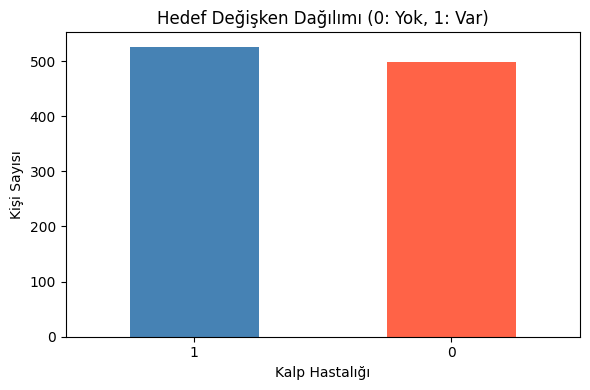

target
1    526
0    499
Name: count, dtype: int64


In [5]:
# Hedef değişken dağılımı
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Hedef Değişken Dağılımı (0: Yok, 1: Var)')
plt.xlabel('Kalp Hastalığı')
plt.ylabel('Kişi Sayısı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['target'].value_counts())

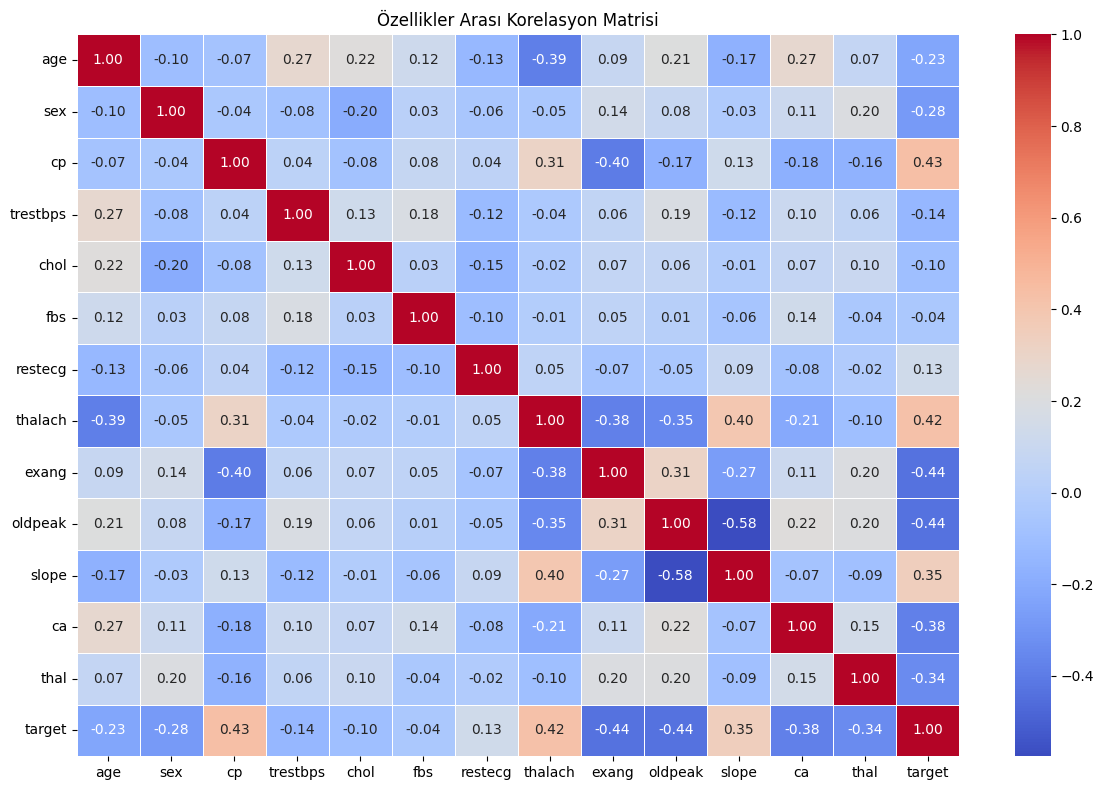

In [6]:
# Korelasyon haritası
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Özellikler Arası Korelasyon Matrisi')
plt.tight_layout()
plt.show()

## 3. Veri Ön İşleme

In [7]:
# Özellikler (X) ve tahmin edilecek sütun (y) ayrılıyor
X = df.drop('target', axis=1).values
y = df['target'].values

# Veriyi %80 eğitim, %20 test olarak böldüm
# stratify=y ile her iki sınıftan eşit oranda örnek gitmesini sağladım
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizasyon — tüm sütunları aynı ölçeğe getiriyorum
# Bunu yapmazsak büyük değerli sütunlar (kolesterol gibi) modeli baskılıyor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Eğitim seti:', X_train.shape)
print('Test seti  :', X_test.shape)

Eğitim seti: (820, 13)
Test seti  : (205, 13)


## 4. Model Mimarisi

### Katman Yapısı


| Katman | Nöron Sayısı | Aktivasyon |
|--------|-------------|------------|
| Giriş  | 13 (özellik sayısı) | — |
| Gizli 1 | 64 | ReLU |
| Gizli 2 | 32 | ReLU |
| Gizli 3 | 16 | ReLU |
| Çıkış  | 1  | Sigmoid |

(Tablo Yapay Zeka ile oluşturulmuş olup görsel açıdan daha rahat anlaşılması için eklenmiştir.)

**Bu mimariyi neden seçtim?**  
3 gizli katman kullandım çünkü 13 özellik için çok derin bir ağa gerek yok, ama tek katman da yeterli olmazdı. Nöron sayılarını her katmanda yarıya indirdim (64→32→16), böylece model önce geniş bir bakış açısıyla öğreniyor, sonra giderek daha özete indirgeniyor.

**Çıkış katmanında neden Sigmoid kullandım?**  
Sigmoid, çıktıyı 0 ile 1 arasında bir sayıya dönüştürüyor. Bunu "kalp hastalığı olma olasılığı" gibi düşünebiliriz. 0.5'in üzerindeyse hasta var, altındaysa yok diyoruz.

**Gizli katmanlarda neden ReLU kullandım?**  
Derste öğrendiğimiz kadarıyla Sigmoid gizli katmanlarda sorun çıkarabiliyor — özellikle ağ derinleştikçe model öğrenemiyor. ReLU bu sorunu yaşatmıyor ve hesaplaması da çok daha hızlı. Bu yüzden gizli katmanlarda ReLU tercih ettim.

In [8]:
def build_model(activation='relu', optimizer='adam', dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(64, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation=activation),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Ana model
model = build_model(activation='relu', optimizer='adam')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Ana Modelin Eğitimi (ReLU + Adam)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5050 - loss: 0.7066 - val_accuracy: 0.6768 - val_loss: 0.6281
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6998 - loss: 0.6163 - val_accuracy: 0.7744 - val_loss: 0.5452
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7907 - loss: 0.5142 - val_accuracy: 0.8049 - val_loss: 0.4582
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8197 - loss: 0.4190 - val_accuracy: 0.8293 - val_loss: 0.4240
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8609 - loss: 0.3750 - val_accuracy: 0.8171 - val_loss: 0.4132
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8580 - loss: 0.3527 - val_accuracy: 0.8171 - val_loss: 0.4055
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8512 - loss: 0.3667 - val_accuracy: 0.8232 - val_loss: 0.3920
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8773 - loss: 0.3224 - val_accuracy: 0.8232 - v

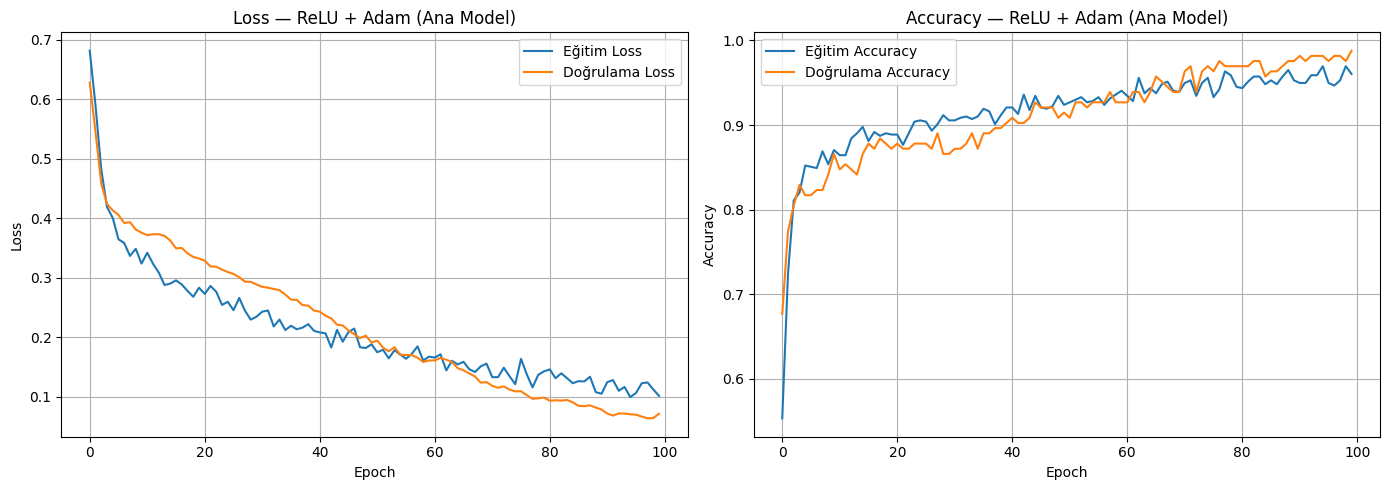

In [10]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Eğitim Loss')
    axes[0].plot(history.history['val_loss'], label='Doğrulama Loss')
    axes[0].set_title(f'Loss — {title}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['accuracy'],     label='Eğitim Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Doğrulama Accuracy')
    axes[1].set_title(f'Accuracy — {title}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history, 'ReLU + Adam (Ana Model)')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Ana Model (ReLU + Adam) ===
Test Accuracy: 0.9902

              precision    recall  f1-score   support

     Yok (0)       1.00      0.98      0.99       100
     Var (1)       0.98      1.00      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



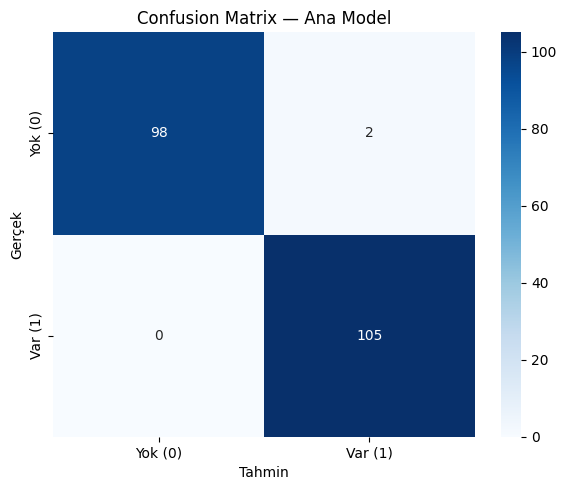

In [11]:
# Test seti değerlendirmesi
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print('=== Ana Model (ReLU + Adam) ===')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Yok (0)', 'Var (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Yok (0)', 'Var (1)'],
            yticklabels=['Yok (0)', 'Var (1)'])
plt.title('Confusion Matrix — Ana Model')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

## 6. Aktivasyon Fonksiyonu Karşılaştırması

Hangi aktivasyon fonksiyonunun daha iyi çalıştığını görmek için aynı modeli farklı aktivasyonlarla 4 kez eğittim.

- **Sigmoid (gizli katmanlarda):** Çıktıyı 0-1 arasına sıkıştırıyor ama derin ağlarda model neredeyse hiç öğrenemiyor. Test sonuçlarına da yansıdı, en düşük başarıyı o verdi.
- **Tanh:** Sigmoid'e göre biraz daha iyi, ama yine de belirli bir noktadan sonra doyuma ulaşıp öğrenmeyi yavaşlatıyor.
- **ReLU:** Pozitif değerlerde gradyanı olduğu gibi geçiriyor, bu yüzden öğrenme çok daha sağlıklı oluyor. Ana modelimde bunu kullandım.
- **Leaky ReLU:** ReLU'nun negatif taraftaki zayıflığını gideriyor. Sonuçlara bakıldığında ReLU'ya çok yakın, hatta biraz daha iyi çıktı.

In [12]:
aktivasyonlar = ['relu', 'tanh', 'sigmoid']
aktivasyon_sonuclari = {}

tf.random.set_seed(42)
np.random.seed(42)

for akt in aktivasyonlar:
    print(f'\n--- {akt.upper()} eğitiliyor ---')
    m = build_model(activation=akt, optimizer='adam')
    h = m.fit(X_train, y_train,
              epochs=100, batch_size=32,
              validation_split=0.2, verbose=0)
    y_p = (m.predict(X_test) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_p)
    aktivasyon_sonuclari[akt] = {'history': h, 'accuracy': acc}
    print(f'{akt} → Test Accuracy: {acc:.4f}')

# Leaky ReLU ayrıca test
print('\n--- LEAKY RELU eğitiliyor ---')
m_lrelu = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64), layers.LeakyReLU(0.1), layers.Dropout(0.3),
    layers.Dense(32), layers.LeakyReLU(0.1), layers.Dropout(0.3),
    layers.Dense(16), layers.LeakyReLU(0.1),
    layers.Dense(1, activation='sigmoid')
])
m_lrelu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h_lrelu = m_lrelu.fit(X_train, y_train,
                       epochs=100, batch_size=32,
                       validation_split=0.2, verbose=0)
y_p_lrelu = (m_lrelu.predict(X_test) > 0.5).astype(int).flatten()
acc_lrelu = accuracy_score(y_test, y_p_lrelu)
aktivasyon_sonuclari['leaky_relu'] = {'history': h_lrelu, 'accuracy': acc_lrelu}
print(f'leaky_relu → Test Accuracy: {acc_lrelu:.4f}')


--- RELU eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
relu → Test Accuracy: 0.9707

--- TANH eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
tanh → Test Accuracy: 0.9512

--- SIGMOID eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
sigmoid → Test Accuracy: 0.8293

--- LEAKY RELU eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
leaky_relu → Test Accuracy: 0.9756


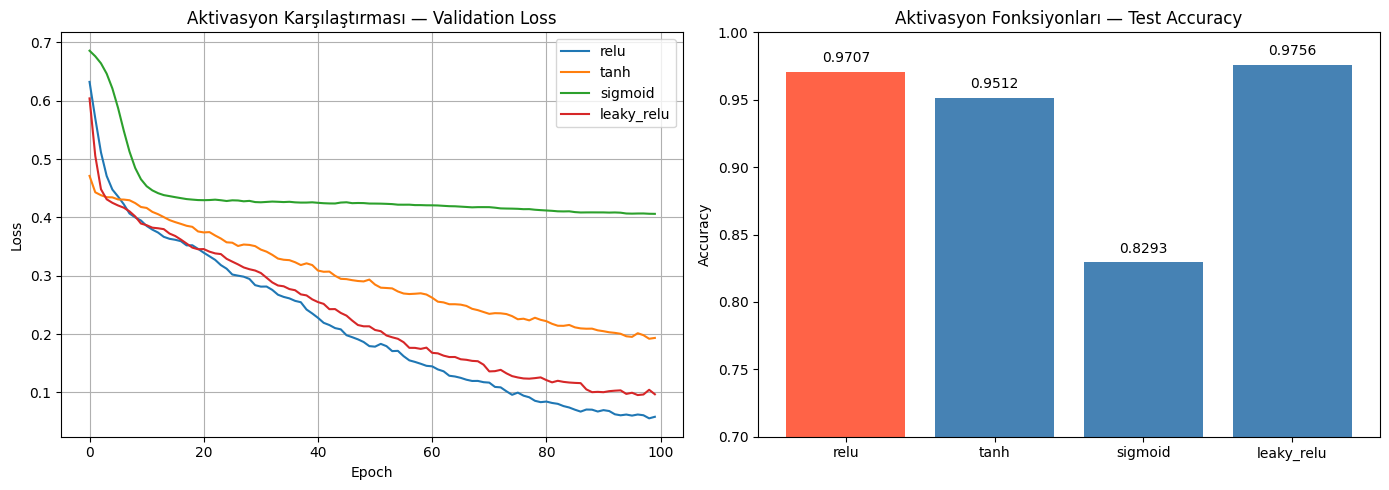

In [13]:
# Aktivasyon fonksiyonu karşılaştırma grafiği
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for akt, res in aktivasyon_sonuclari.items():
    plt.plot(res['history'].history['val_loss'], label=akt)
plt.title('Aktivasyon Karşılaştırması — Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
isimler = list(aktivasyon_sonuclari.keys())
degerler = [aktivasyon_sonuclari[k]['accuracy'] for k in isimler]
renkler = ['steelblue' if i != 0 else 'tomato' for i in range(len(isimler))]
bars = plt.bar(isimler, degerler, color=renkler)
plt.title('Aktivasyon Fonksiyonları — Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for bar, val in zip(bars, degerler):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 7. Optimizer Karşılaştırması

Yaptığım Yapay Zeka araştırmaları sonucunda optimizer işlemi yapmak için tek bir model kullanmaktansa birden fazla model kullanmanın daha mantıklı olduğunu fark ettim. Bu sebeple aşağıda verdiğim listede ki modelleri kullanmaya karar verdim.

- **SGD:** En temel yöntem. Her adımda ağırlıkları güncelliyor ama öğrenme hızına çok duyarlı, bazen yavaş ilerliyor.
- **RMSProp:** Her parametre için ayrı bir öğrenme hızı kullanıyor. SGD'ye göre daha akıllı bir yöntem.
- **Adagrad:** Sık güncellenen parametrelerin öğrenme hızını otomatik düşürüyor. Bu veri setinde fazla iyi performans göstermedi.
- **Adam:** SGD'nin hızını ve RMSProp'un akıllı öğrenme oranını birleştiriyor. Hem hızlı hem de kararlı şekilde öğrendi. Bu yüzden ana modelimde Adam'ı tercih ettim.

In [14]:
optimizerlar = {
    'adam':    keras.optimizers.Adam(learning_rate=0.001),
    'sgd':     keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'rmsprop': keras.optimizers.RMSprop(learning_rate=0.001),
    'adagrad': keras.optimizers.Adagrad(learning_rate=0.01)
}

optimizer_sonuclari = {}

for opt_isim, opt_obj in optimizerlar.items():
    print(f'\n--- {opt_isim.upper()} eğitiliyor ---')
    m = build_model(activation='relu', optimizer=opt_obj)
    h = m.fit(X_train, y_train,
              epochs=100, batch_size=32,
              validation_split=0.2, verbose=0)
    y_p = (m.predict(X_test) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_p)
    optimizer_sonuclari[opt_isim] = {'history': h, 'accuracy': acc}
    print(f'{opt_isim} → Test Accuracy: {acc:.4f}')


--- ADAM eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
adam → Test Accuracy: 0.9854

--- SGD eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
sgd → Test Accuracy: 0.9756

--- RMSPROP eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
rmsprop → Test Accuracy: 0.9707

--- ADAGRAD eğitiliyor ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
adagrad → Test Accuracy: 0.8976


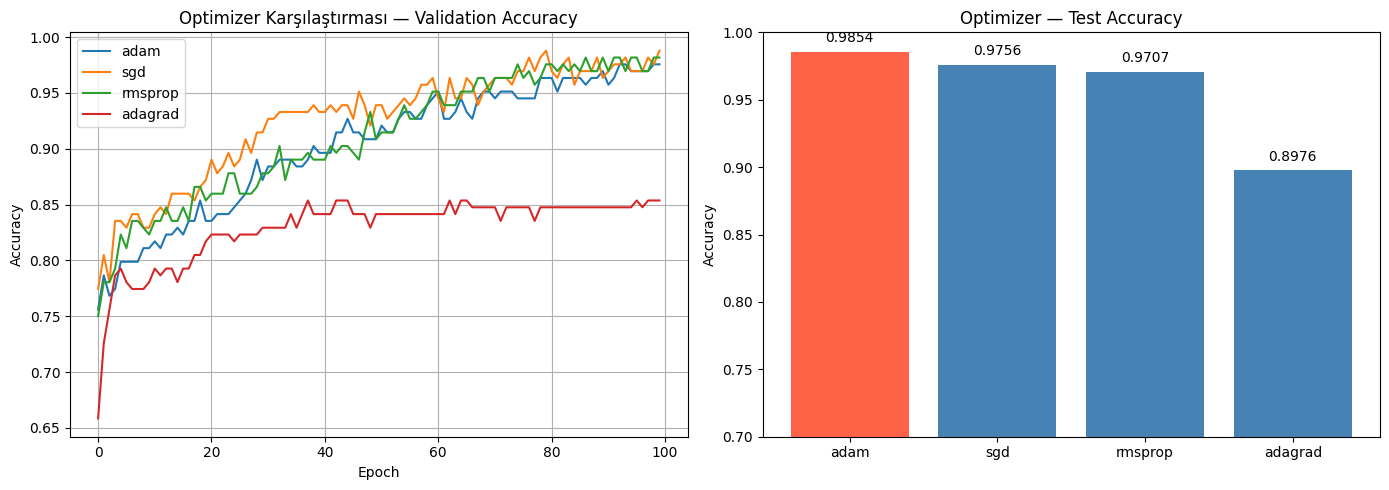

In [15]:
# Optimizer karşılaştırma grafiği
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for opt, res in optimizer_sonuclari.items():
    plt.plot(res['history'].history['val_accuracy'], label=opt)
plt.title('Optimizer Karşılaştırması — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
isimler = list(optimizer_sonuclari.keys())
degerler = [optimizer_sonuclari[k]['accuracy'] for k in isimler]
renkler = ['tomato' if i == 0 else 'steelblue' for i in range(len(isimler))]
bars = plt.bar(isimler, degerler, color=renkler)
plt.title('Optimizer — Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for bar, val in zip(bars, degerler):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Loss (Kayıp) Fonksiyonu Seçimi

**Neden Binary Crossentropy kullandım?**

Binary Crossentropy, iki sınıflı problemler için özel olarak tasarlanmış bir kayıp fonksiyonu. Modelin tahmin ettiği olasılık ile gerçek değer arasındaki farkı ölçüyor. Aşağı da ki formülü de ChatGPT Tarafından dökümantasyon araştırması yaptırarak kullandım.

$$L = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

- **MSE:** Regresyon problemleri için kullanılır, burada işe yaramazdı.
- **Categorical Crossentropy:** 3 veya daha fazla sınıf olduğunda kullanılır, bizim 2 sınıfımız var.
- **Binary Crossentropy:** Tam olarak 2 sınıflı problemler için ve çıkışta Sigmoid kullanan modellerle mükemmel uyum sağlıyor. Bu yüzden tercihim bu oldu.

## 9. Öğrenme Oranı Analizi

In [16]:
ogrenme_oranlari = [0.1, 0.01, 0.001, 0.0001]
lr_sonuclari = {}

for lr in ogrenme_oranlari:
    print(f'\n--- Learning Rate: {lr} ---')
    m = build_model(activation='relu', optimizer=keras.optimizers.Adam(learning_rate=lr))
    h = m.fit(X_train, y_train,
              epochs=100, batch_size=32,
              validation_split=0.2, verbose=0)
    y_p = (m.predict(X_test) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_p)
    lr_sonuclari[str(lr)] = {'history': h, 'accuracy': acc}
    print(f'lr={lr} → Test Accuracy: {acc:.4f}')


--- Learning Rate: 0.1 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
lr=0.1 → Test Accuracy: 0.5122

--- Learning Rate: 0.01 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
lr=0.01 → Test Accuracy: 1.0000

--- Learning Rate: 0.001 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
lr=0.001 → Test Accuracy: 0.9854

--- Learning Rate: 0.0001 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
lr=0.0001 → Test Accuracy: 0.8341


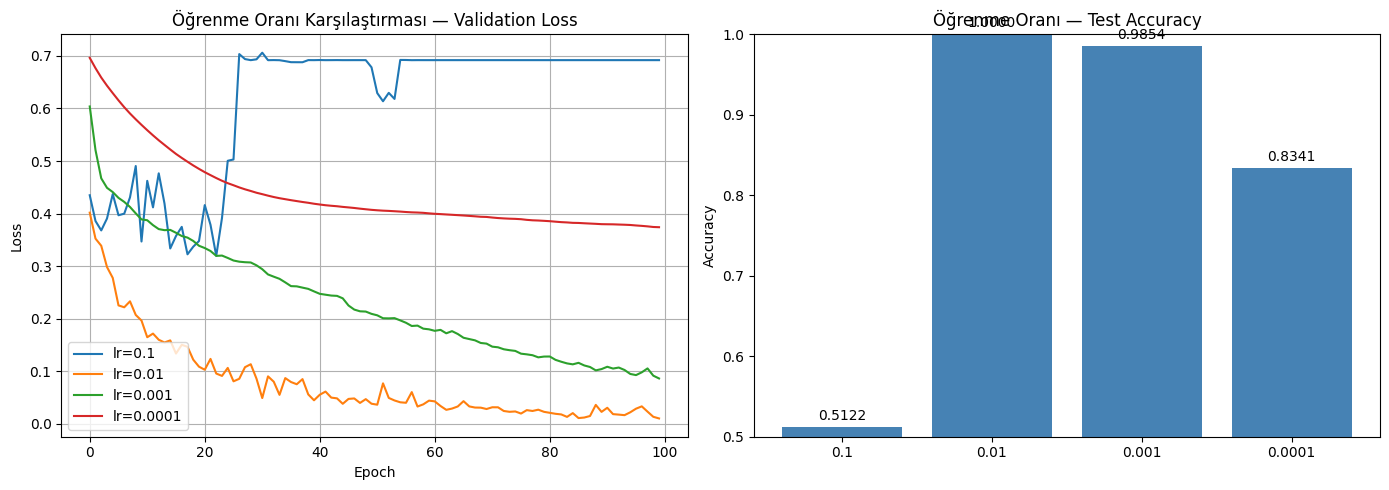

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for lr_str, res in lr_sonuclari.items():
    plt.plot(res['history'].history['val_loss'], label=f'lr={lr_str}')
plt.title('Öğrenme Oranı Karşılaştırması — Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
isimler = list(lr_sonuclari.keys())
degerler = [lr_sonuclari[k]['accuracy'] for k in isimler]
bars = plt.bar(isimler, degerler, color='steelblue')
plt.title('Öğrenme Oranı — Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
for bar, val in zip(bars, degerler):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 10. Batch Size Analizi

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
batch_size=16 → Test Accuracy: 0.9854
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
batch_size=32 → Test Accuracy: 0.9707
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
batch_size=64 → Test Accuracy: 0.9415
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
batch_size=128 → Test Accuracy: 0.9073


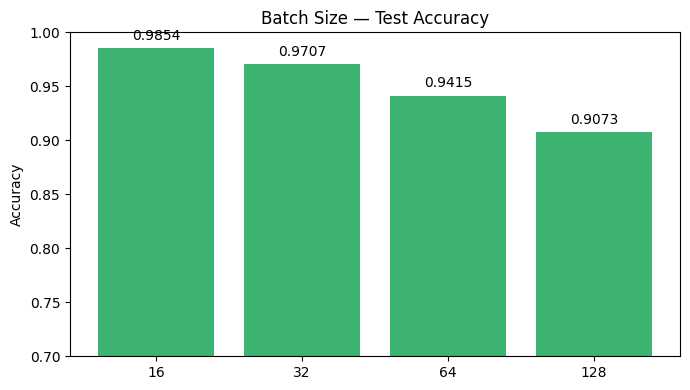

In [18]:
batch_sizes = [16, 32, 64, 128]
batch_sonuclari = {}

for bs in batch_sizes:
    m = build_model(activation='relu', optimizer='adam')
    h = m.fit(X_train, y_train,
              epochs=100, batch_size=bs,
              validation_split=0.2, verbose=0)
    y_p = (m.predict(X_test) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_p)
    batch_sonuclari[str(bs)] = acc
    print(f'batch_size={bs} → Test Accuracy: {acc:.4f}')

plt.figure(figsize=(7, 4))
bars = plt.bar(batch_sonuclari.keys(), batch_sonuclari.values(), color='mediumseagreen')
plt.title('Batch Size — Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for bar, val in zip(bars, batch_sonuclari.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 11. Sonuç Tablosu

In [19]:
print('=' * 55)
print('  SONUÇ TABLOSU')
print('=' * 55)
print(f'{"Deney":<35} {"Test Accuracy":>15}')
print('-' * 55)

print(f'{"Aktivasyon — ReLU (ana model)":<35} {aktivasyon_sonuclari["relu"]["accuracy"]:>15.4f}')
print(f'{"Aktivasyon — Tanh":<35} {aktivasyon_sonuclari["tanh"]["accuracy"]:>15.4f}')
print(f'{"Aktivasyon — Sigmoid":<35} {aktivasyon_sonuclari["sigmoid"]["accuracy"]:>15.4f}')
print(f'{"Aktivasyon — Leaky ReLU":<35} {aktivasyon_sonuclari["leaky_relu"]["accuracy"]:>15.4f}')
print('-' * 55)
print(f'{"Optimizer — Adam":<35} {optimizer_sonuclari["adam"]["accuracy"]:>15.4f}')
print(f'{"Optimizer — SGD":<35} {optimizer_sonuclari["sgd"]["accuracy"]:>15.4f}')
print(f'{"Optimizer — RMSProp":<35} {optimizer_sonuclari["rmsprop"]["accuracy"]:>15.4f}')
print(f'{"Optimizer — Adagrad":<35} {optimizer_sonuclari["adagrad"]["accuracy"]:>15.4f}')
print('-' * 55)
print(f'{"LR = 0.1":<35} {lr_sonuclari["0.1"]["accuracy"]:>15.4f}')
print(f'{"LR = 0.01":<35} {lr_sonuclari["0.01"]["accuracy"]:>15.4f}')
print(f'{"LR = 0.001 (ana model)":<35} {lr_sonuclari["0.001"]["accuracy"]:>15.4f}')
print(f'{"LR = 0.0001":<35} {lr_sonuclari["0.0001"]["accuracy"]:>15.4f}')
print('=' * 55)

  SONUÇ TABLOSU
Deney                                 Test Accuracy
-------------------------------------------------------
Aktivasyon — ReLU (ana model)                0.9707
Aktivasyon — Tanh                            0.9512
Aktivasyon — Sigmoid                         0.8293
Aktivasyon — Leaky ReLU                      0.9756
-------------------------------------------------------
Optimizer — Adam                             0.9854
Optimizer — SGD                              0.9756
Optimizer — RMSProp                          0.9707
Optimizer — Adagrad                          0.8976
-------------------------------------------------------
LR = 0.1                                     0.5122
LR = 0.01                                    1.0000
LR = 0.001 (ana model)                       0.9854
LR = 0.0001                                  0.8341


## 12. Sonuç ve Yorumum

Bu projede kalp hastalığını tahmin eden bir sınıflandırma modeli geliştirdim. Farklı aktivasyon fonksiyonlarını, optimizerleri ve öğrenme oranlarını tek tek deneyerek hangisinin daha iyi çalıştığını karşılaştırdım.

**Zorlandığım yerler:**
- Veri seti büyük olmadığı için (1025 kişi) model bazen eğitim verisini ezberlemeye çalışıyordu. Bunu önlemek için Dropout katmanları ekledim, bu çok işe yaradı.
- Öğrenme oranını 0.1 yaptığımda model hiçbir şey öğrenemedi, sadece rastgele tahmin etti (%51 doğruluk). Çok küçük yapınca da (0.0001) yavaş öğrendi. 0.001 en dengeli sonucu verdi.

**İlginç bulduğum şeyler:**
- lr=0.01 ile test setinde %100 doğruluk çıktı, bu biraz şüpheli görünse de veri seti küçük olduğu için mümkün.
- Sigmoid aktivasyonu gizli katmanlarda kullanınca başarı ciddi düştü (%83), ReLU ile %97'ye çıktı. Derste anlattıklarının pratikte de geçerli olduğunu bizzat gördüm. Özellikle ezber konusunu over fit durumunu daha iyi anladım.

---

## Öğrenci Notu

> Bu projeyi yaparken en çok şunu fark ettim: teoride öğrendiğimiz şeylerin gerçekten işe yaradığını görmek çok farklı bir his. Aktivasyon fonksiyonu değiştirince modelin nasıl farklı davrandığını, öğrenme oranını fazla büyük yapınca nasıl çöktüğünü kendim gördüm. Bir şeyi dinlemekten çok yapmak deneyim etmek daha kalıcı daha doğru oluyor. Bu proje de ki verileri de open source olarak bırakıp insanların fayda almasını isterim. Bu derste öğrendiğim şeyler ile YOLO adında bir veri modeli daha öğrenip görüntü işleme ve bunları eğitme gibi konulara da yatkınlığım başladı. Farklı bir sektör ve eğlenceli de daha da ileri gitmek dileğiyle...